In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from scipy import linalg as la
from tqdm import tqdm
import pickle
import seaborn as sns
import cmasher as cmr
import kwant
import scipy.optimize as optimize
import scipy.integrate as integrate

from koala import plotting as pl

from alter_morph.mean_field import hartree_fock
from alter_morph.kwant_utilities import (
    crack_hamiltonian_for_contacts_kwant,
    attach_leads_to_cracked,
)
from alter_morph.hamiltonians import (
    alt_hamiltonian,
    spectral_function,
    _hopping_matrix,
    find_m_per_state,
    find_spin_per_state,
    spectral_path,
)

aps_figwidth = 3.375 * 2
aps_halfwidth = 3.375

matplotlib.rcParams.update(
    {
        "font.size": 10,
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Times"],
    }
)

aps_figwidth

/opt/homebrew/Caskroom/miniforge/base/envs/kwant-test/lib/python3.12/site-packages/kwant/solvers/default.py:16: RuntimeWarning: MUMPS is not available, SciPy built-in solver will be used as a fallback. Performance can be very poor in this case.
  warnings.warn("MUMPS is not available, "


6.75

In [3]:
def fermi_level(energies, filling):
    return np.mean(
        energies[int(filling * len(energies)) - 1 : int(filling * len(energies)) + 1]
    )


def dos_at_fermi(energies, fermi_energy, broadening):
    norm_lorenzian = (1 / np.pi) * (
        broadening / ((energies - fermi_energy) ** 2 + broadening**2)
    )
    return np.mean(norm_lorenzian)


def derivative_FD(energy, temperature):
    return 1 / (4 * temperature) / np.cosh(energy / (2 * temperature)) ** 2


def find_int_points_FD(temperature, n):
    """
    finds the ideal integration points x_i and weights w_i to evaluate the integral
    int_{-infinity}^{infinity} f(x) n_FD'(x,temperature) dx = sum_i f(x_i) * n_FD'(x_i,temperature) * w_i
    ### input ###
    temperature: temperatue in the derivative of the Fermi-Dirac function n_FD'
    n: number of integration points to choose

    ### output ###
    integration points x, weights
    """
    if temperature == 0.0:
        print("n not considered")
        return [0], [1]

    # this is outdated:
    # energies = np.linspace(-10*temperature,10*temperature,500)
    # fs = derivative_FD(energies,temperature)
    # popt,_ = optimize.curve_fit(gaussian,energies,fs,p0=temperature*1.6)
    # perfect fitted gaussian has
    # sigma = 1.6296046 * temperature
    # #########################

    # Get Gauss-Hermite quadrature nodes and weights
    # x, weights = np.polynomial.hermite.hermgauss(n)
    # x = x * sigma * 2**0.5 # Transform nodes to match Gaussian width sigma
    # weights = weights /np.pi**0.5 #Transform weights to match unnormalized Gaussian
    ###########################
    ###########################

    # Get Gauss-Legendre quadrature nodes and weights
    def integral_int_boundary(integration_boundary, temperature, n):
        """integrate the raw FD function and compare them to get good integration boundary"""
        xs = np.linspace(-10 * temperature, 10 * temperature, 500)

        int_exact = integrate.trapezoid(derivative_FD(xs, temperature), xs)
        x, weights = np.polynomial.legendre.leggauss(n)
        int_prox = np.sum(
            derivative_FD(x * integration_boundary, temperature)
            * weights
            * integration_boundary
        )
        return int_exact - int_prox

    res = optimize.root(integral_int_boundary, 4, args=(temperature, n))
    optimal_int_boundary = res.x[0]

    x, weights = np.polynomial.legendre.leggauss(n)
    x = x * optimal_int_boundary  # Transform nodes to match integration region
    weights = (
        weights * optimal_int_boundary
    )  # Transform weights to match integration region

    return x, weights

In [4]:
data_name = "data/detailed_phase_diagram_20_V0"
lattice_name = "analysis/voronoi_20"
# load data
with open(data_name + ".pickle", "rb") as f:
    data = pickle.load(f)

# load lattice
with open(lattice_name + ".pickle", "rb") as f:
    lattice = pickle.load(f)

point_A = (0.1, 0.5)
point_B = (0.6, 0.15)
point_C = (0.6, 0.85)

In [5]:
data["data"][0, 0].keys()

dict_keys(['hparam', 'energies', 'numerical_param', 'spin_cond'])

figure 1: a phase diagram

In [6]:
# process the data

fillings = data["filling"]
J_vals = data["J"]

all_avg_mags = np.zeros([len(fillings), len(J_vals)])
all_variance_mags = np.zeros([len(fillings), len(J_vals)])

all_bond_diff_m = np.zeros([len(fillings), len(J_vals)])
all_bond_diff_n = np.zeros([len(fillings), len(J_vals)])
all_prop_relative_m = np.zeros([len(fillings), len(J_vals)])

all_energies = np.zeros([len(fillings), len(J_vals), lattice.n_vertices * 4])
broadening = 0.1

conds = np.zeros([len(fillings), len(J_vals), 2])

for i, filling in enumerate(tqdm(fillings)):
    for j, J in enumerate(J_vals):
        current_data = data["params"][i, j]

        # calculate the average magnetization
        all_avg_mags[i, j] = np.mean(current_data["m"])
        all_variance_mags[i, j] = np.var(current_data["n"])

        all_prop_relative_m[i, j] = np.mean(current_data["m"]) / np.max(
            current_data["m"]
        )

        all_energies[i, j] = data["data"][i, j]["energies"]
        conds[i, j] = data["data"][i, j]["spin_cond"].diagonal()

        # # calculate the density of states
        # all_dos_vals[i, j] = dos_at_fermi(
        #     all_energies[i, j], fermi_level(all_energies[i, j], filling), broadening
        # )

        # difference in m on bonds
        m = data["params"][i, j]["m"]
        m_on_bonds = m[lattice.edges.indices]
        all_bond_diff_m[i, j] = np.abs(m_on_bonds[:, 0] - m_on_bonds[:, 1]).mean()

        # difference in n on bonds
        n = data["params"][i, j]["n"]
        n_on_bonds = n[lattice.edges.indices]
        all_bond_diff_n[i, j] = np.abs(n_on_bonds[:, 0] - n_on_bonds[:, 1]).mean()

100%|██████████| 41/41 [00:00<00:00, 238.46it/s]


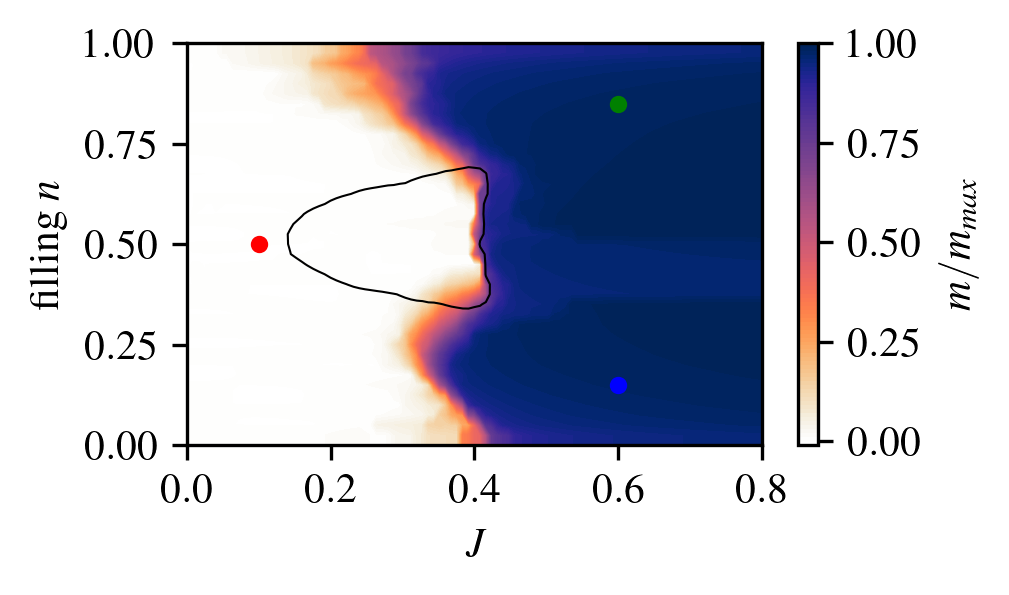

In [17]:
fig, ax = plt.subplots(1, 1, figsize=(aps_halfwidth, aps_halfwidth / 1.618), dpi=300)


points = [point_A, point_B, point_C]
argpoints = []
for i in range(3):
    point = points[i]
    arg_J = np.argmin(np.abs(J_vals - point[0]))
    arg_filling = np.argmin(np.abs(fillings - point[1]))
    argpoints.append((arg_J, arg_filling))
    point = (J_vals[arg_J], fillings[arg_filling])
    points[i] = point

# plot the n on bonds
max_poss_mag = 2 - np.abs(4 * fillings - 2)
max_poss_mag[0] = 0.1
max_poss_mag[-1] = 0.1
all_avg_mags[0] = all_avg_mags[1]
all_avg_mags[-1] = all_avg_mags[-2]

scaled_mag = all_avg_mags / max_poss_mag[:, None]
# scaled_mag[np.where(scaled_mag>1)] =1


# plot the average magnetization
vlims = [0, 1.2]
im = ax.contourf(
    J_vals,
    fillings,
    scaled_mag,
    levels=100,
    cmap=cmr.torch_r,
    vmin=vlims[0],
    vmax=vlims[1],
)

# im2 = ax.contour(J_vals, fillings, all_avg_mags, levels=[0.2], colors="black", linewidths=0.5)
im2 = ax.contour(
    J_vals, fillings, all_bond_diff_n, levels=[0.5], colors="black", linewidths=0.5
)

clims = (0, 1)
cbar = fig.colorbar(im, ax=ax, ticks=np.linspace(clims[0], clims[1], 5))

# ax.set_ylim(fillings[1],fillings[-2])
ax.set_xlabel(r"$J$")
ax.set_ylabel(r"filling $n$")
cbar.set_label(r"$ m / m_{\tiny{\small{max}}}$")


ax.scatter([point_A[0]], [point_A[1]], color="red", s=10)
ax.scatter([point_B[0]], [point_B[1]], color="blue", s=10)
ax.scatter([point_C[0]], [point_C[1]], color="green", s=10)

plt.tight_layout()
plt.savefig("paper_figs/fig_1.pdf")
plt.show()

# fig, ax = plt.subplots(1, 1, figsize=(aps_halfwidth, aps_halfwidth / 1.618), dpi=300)

# # plot the n on bonds
# im2 = ax.contour(
#     J_vals, fillings, all_avg_mags, levels=[0.05], colors="black", linewidths=0.5
# )

# # im = ax.contourf(J_vals, fillings, all_bond_diff_n, levels=100, cmap=cmr.amethyst_r)
# # # im = ax.contourf(J_vals, fillings, all_prop_relative_m, levels=100, cmap='terrain_r')
# cbar = fig.colorbar(im, ax=ax, ticks=np.linspace(clims[0], clims[1], 5))
# ax.set_xlabel(r"$J$")
# ax.set_ylabel(r"filling $n$")
# cbar.set_label(r"$\langle m \rangle / m_{\tiny{\small{max}}}$")

# # ax.scatter([point_A[0]], [point_A[1]], color="red", s=10)
# # ax.scatter([point_B[0]], [point_B[1]], color="blue", s=10)
# # ax.scatter([point_C[0]], [point_C[1]], color="green", s=10)

# plt.tight_layout()
# # plt.savefig("paper_figs/fig_1_overlay.pdf")
# plt.show()

In [8]:
broadening = 0.2
nk = 100
n_energy = 200
n_path = 300
path = np.array([[1, 1], [1, 0], [0, 0], [0, 1], [1, 1]])

combined = []
spin_resolved = []
spin_up = []
spin_down = []
spectral_paths = []
spectral_paths_diffs = []
each_energies = []
each_fermi_level = []


for i in range(3):
    j_arg, fil_arg = argpoints[i]

    parameters_at_point = data["params"][fil_arg, j_arg]
    parameters_for_run = {
        "t1": parameters_at_point["t1"],
        "t2": parameters_at_point["t2"],
        "J": parameters_at_point["J"],
        "U": parameters_at_point["U"],
        "filling": parameters_at_point["filling"],
        "initial_m": parameters_at_point["m"],
        "initial_n": parameters_at_point["n"],
        "theta_offset": 0,
    }
    hamiltonian_at_point = alt_hamiltonian(
        lattice,
        parameters_for_run["t1"],
        parameters_for_run["t2"],
        parameters_for_run["J"],
        parameters_for_run["U"],
        parameters_for_run["initial_m"],
        parameters_for_run["initial_n"],
        parameters_for_run["theta_offset"],
    )

    energies_at_point, states_at_point = la.eigh(hamiltonian_at_point)

    fermi_energy_at_point = fermi_level(
        energies_at_point, parameters_for_run["filling"]
    )

    specs_at_point = [
        spectral_function(
            lattice,
            energies_at_point,
            states_at_point,
            fermi_energy_at_point,
            local_operator=np.eye(4)[i],
            eta=broadening,
            n_k=nk,
        )
        for i in range(4)
    ]

    spectral_path_at_point = spectral_path(
        lattice,
        energies_at_point,
        states_at_point,
        eta=broadening,
        n_k=n_path,
        n_energy=n_energy,
        local_operator=np.array([1, 1, 1, 1]),
        path=path,
    )
    spectral_path_at_point_diff = spectral_path(
        lattice,
        energies_at_point,
        states_at_point,
        eta=broadening,
        n_k=n_path,
        n_energy=n_energy,
        local_operator=np.array([1, 1, -1, -1]),
        path=path,
    )

    spectral_paths.append(spectral_path_at_point)
    spectral_paths_diffs.append(spectral_path_at_point_diff)

    combined.append(np.sum(specs_at_point, axis=0))
    spin_resolved.append(
        specs_at_point[0] + specs_at_point[1] - specs_at_point[2] - specs_at_point[3]
    )
    spin_up.append(specs_at_point[0] + specs_at_point[1])
    spin_down.append(specs_at_point[2] + specs_at_point[3])

    each_energies.append(energies_at_point)
    each_fermi_level.append(fermi_energy_at_point)

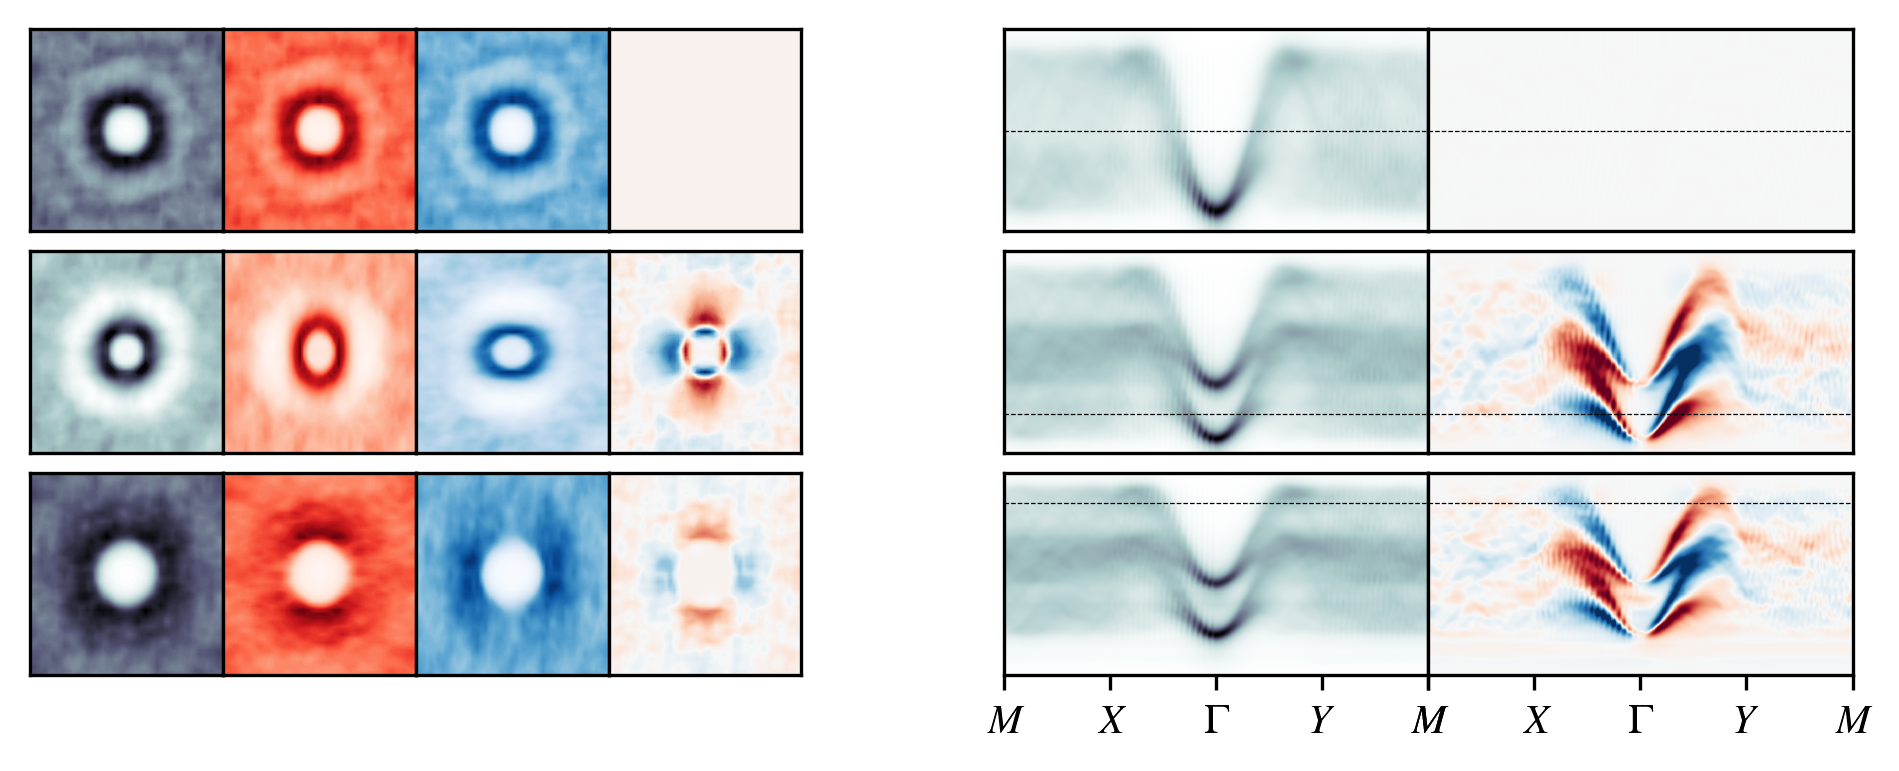

In [9]:
fig = plt.figure(
    figsize=(aps_figwidth, (3 / 4) * aps_halfwidth),
    dpi=300,
)

subfigs = fig.subfigures(1, 2, width_ratios=[1, 1.1], wspace=0)
axs0 = subfigs[0].subplots(3, 4, sharex=True, sharey=True)
axs1 = subfigs[1].subplots(3, 2)
subfigs[0].subplots_adjust(
    hspace=0.1, wspace=0.0, left=0.1, right=0.9, top=0.95, bottom=0.1
)
subfigs[1].subplots_adjust(
    hspace=0.1, wspace=0.0, left=0.1, right=0.9, top=0.95, bottom=0.1
)
# subfigs[0].set_facecolor('lightblue')
# subfigs[1].set_facecolor('yellow')
for a in axs0.flatten():
    a.set_xticks([])
    a.set_yticks([])
    a.set_xlim(-np.pi * 50, np.pi * 50)
    a.set_ylim(-np.pi * 50, np.pi * 50)

for a in axs1.flatten():
    a.set_yticks([])

#################################
## plot the spectral functions ##
#################################


max_comb, min_comb = np.max(combined), np.min(combined)
max_spin, min_spin = np.max(spin_resolved), np.min(spin_resolved)
min_down, max_down = np.min(spin_down), np.max(spin_down)
min_up, max_up = np.min(spin_up), np.max(spin_up)

k_vals = np.arange(-nk // 2, nk // 2) * 2 * np.pi
ks = np.array(np.meshgrid(k_vals, k_vals))

for i in range(3):
    axs0[i, 0].contourf(
        ks[0],
        ks[1],
        combined[i],
        cmap="bone_r",
        origin="lower",
        levels=100,
        # vmin=min_comb,
        # vmax=max_comb,
    )
    axs0[i, 1].contourf(
        ks[0],
        ks[1],
        spin_down[i],
        cmap="Reds",
        origin="lower",
        levels=100,
        # vmin=min_up,
        # vmax=max(spin_up[i]),
    )
    axs0[i, 2].contourf(
        ks[0],
        ks[1],
        spin_up[i],
        cmap="Blues",
        origin="lower",
        levels=100,
        # vmin=min_down,
        # vmax=max_down,
    )
    axs0[i, 3].contourf(
        ks[0],
        ks[1],
        spin_resolved[i],
        cmap="RdBu",
        origin="lower",
        levels=100,
        vmin=min_spin,
        vmax=max_spin,
    )

    # ax[0,i].set_xlabel(r"$k_x$")
    # ax[1,i].set_xlabel(r"$k_x$")
    # ax[0, 0].set_ylabel(r"$k_y$")
    # ax[1, 0].set_ylabel(r"$k_y$")
    # ax[0, i].set_xticks([])
    # ax[0, i].set_yticks([])


#################################
######### plot the paths#########
#################################
extremum_diff = np.max(np.abs(spectral_paths_diffs)) / 1.5
for i in range(3):
    path = spectral_paths[i]

    path_diff = spectral_paths_diffs[i]
    fermi_line = each_fermi_level[i]

    energy_vals = np.linspace(
        np.min(each_energies[i]), np.max(each_energies[i]), n_energy
    )
    X, Y = np.meshgrid(np.arange(path.shape[0]), energy_vals)

    axs1[i, 0].axhline(fermi_line, color="black", linestyle="--", linewidth=0.3)
    axs1[i, 1].axhline(fermi_line, color="black", linestyle="--", linewidth=0.3)
    axs1[i, 0].pcolor(X, Y, path.real.T, cmap="bone_r", vmin=0, vmax=np.max(path.real))
    axs1[i, 1].pcolor(
        X, Y, path_diff.real.T, cmap="RdBu", vmin=-extremum_diff, vmax=extremum_diff
    )
    axs1[i, 0].set_yticks([])
    axs1[i, 1].set_yticks([])
    axs1[i, 0].set_xticks([])
    axs1[i, 1].set_xticks([])


axs1[2, 1].set_xticks(np.array([0, 1, 2, 3, 4]) * path.shape[0] // 4)
axs1[2, 1].set_xticklabels([r"$M$", r"$X$", r"$\Gamma$", r"$Y$", r"$M$"])
axs1[2, 0].set_xticks(np.array([0, 1, 2, 3, 4]) * path.shape[0] // 4)
axs1[2, 0].set_xticklabels([r"$M$", r"$X$", r"$\Gamma$", r"$Y$", r"$M$"])


# plt.savefig("paper_figs/fig_2.pdf")

plt.show()

In [ ]:
if False:
    n_fock_steps = 100
    n_angle_steps = 40
    angles = np.linspace(0, np.pi / 2, n_angle_steps, endpoint=False)

    cond_up = np.zeros([3, n_angle_steps])
    cond_down = np.zeros([3, n_angle_steps])
    cross = np.zeros([3, n_angle_steps])
    ms = np.zeros([3, n_angle_steps, lattice.n_vertices])
    ns = np.zeros([3, n_angle_steps, lattice.n_vertices])

    temperature = 0.02
    perfect_int_points, weights = find_int_points_FD(temperature, 21)

    for i in range(3):
        j_arg, fil_arg = argpoints[i]

        parameters_at_point = data["params"][fil_arg, j_arg]
        initial_parameters_for_run = {
            "t1": parameters_at_point["t1"],
            "t2": parameters_at_point["t2"],
            "J": parameters_at_point["J"],
            "U": parameters_at_point["U"],
            "filling": parameters_at_point["filling"],
            "initial_m": parameters_at_point["m"],
            "initial_n": parameters_at_point["n"],
            "theta_offset": 0,
        }

        m_last = initial_parameters_for_run["initial_m"]
        n_last = initial_parameters_for_run["initial_n"]
        for j, theta in enumerate(tqdm(angles)):

            # first find the new m and n
            parameters_for_run = initial_parameters_for_run.copy()
            parameters_for_run["theta_offset"] = theta
            parameters_for_run["initial_m"] = m_last
            parameters_for_run["initial_n"] = n_last

            m_vals, n_vals = hartree_fock(
                lattice,
                parameters_for_run,
                n_fock_steps,
                tol_mdiff=1e6,
                mixing_proportion=0.2,
                verbose=False,
                adjust_learning_rate=True,
            )
            m_last = m_vals[-1]
            n_last = n_vals[-1]

            hamiltonian = alt_hamiltonian(
                lattice,
                parameters_at_point["t1"],
                parameters_at_point["t2"],
                parameters_at_point["J"],
                parameters_at_point["U"],
                m_vals[-1],
                n_vals[-1],
                theta,
            )

            lead_onsite = np.eye(4) * each_fermi_level[i]
            lead_coupling = -np.eye(4)

            contact_lattice, k_lattice, k_system, contact_vertices = (
                crack_hamiltonian_for_contacts_kwant(lattice, hamiltonian)
            )
            kwant_system_with_leads, left_lead, right_lead = attach_leads_to_cracked(
                contact_lattice,
                k_lattice,
                k_system,
                contact_vertices,
                lead_onsite,
                lead_coupling,
                np.diag([-1, -1, 1, 1]),
            )

            k_system_f = k_system.finalized()
            smatrix = kwant.smatrix(k_system_f, energy=each_fermi_level[i])
            # g = np.array(
            #     [[smatrix.transmission((1, j), (0, i)) for j in range(2)] for i in range(2)]
            # )

            g = []
            for energy, weight in zip(
                perfect_int_points + each_fermi_level[i], weights
            ):
                smatrix = kwant.smatrix(k_system_f, energy=energy)
                g_T = np.array(
                    [
                        [smatrix.transmission((1, j), (0, i)) for j in range(2)]
                        for i in range(2)
                    ]
                )
                g.append(g_T * weight)
            g = np.sum(g, axis=0)

            cond_up[i, j] = g[0, 0]
            cond_down[i, j] = g[1, 1]
            cross[i, j] = g[0, 1]

            ms[i, j] = m_vals[-1]
            ns[i, j] = n_vals[-1]

100%|██████████| 40/40 [02:45<00:00,  4.15s/it]


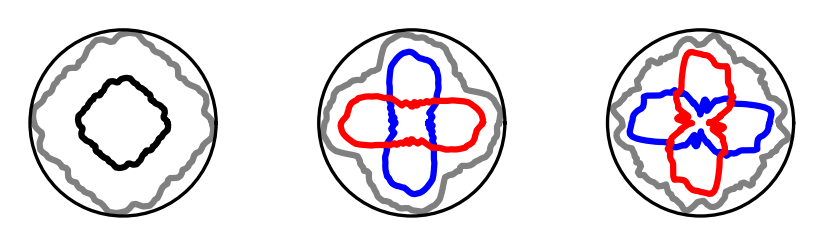

In [25]:
full_cond_up = np.concatenate([cond_up, cond_down, cond_up, cond_down], axis=1)
full_cond_down = np.concatenate([cond_down, cond_up, cond_down, cond_up], axis=1)
full_thetas = np.linspace(0, 2 * np.pi, n_angle_steps * 4, endpoint=False)
# full_cond_up = cond_up
# full_cond_down =  cond_down
# full_thetas = np.linspace(0,np.pi/2, n_angle_steps, endpoint=False)


fig, ax = plt.subplots(
    1,
    3,
    figsize=(aps_halfwidth * 0.9, aps_halfwidth * (1.5 / 5.5)),
    dpi=300,
    subplot_kw={"projection": "polar"},
    sharex=True,
    # sharey=True,
)
# fig, ax = plt.subplots(figsize = (20,4))

total_cond = full_cond_up + full_cond_down
split_angle = (full_cond_up - full_cond_down) / (full_cond_up + full_cond_down)


total_cond = np.concatenate([total_cond, total_cond[:, 0][:, None]], axis=1)
split_angle = np.concatenate([split_angle, split_angle[:, 0][:, None]], axis=1)
full_cond_up = np.concatenate([full_cond_up, full_cond_up[:, 0][:, None]], axis=1)
full_cond_down = np.concatenate([full_cond_down, full_cond_down[:, 0][:, None]], axis=1)
full_thetas = np.concatenate([full_thetas, [2 * np.pi]])

for i in range(3):
    # ax[i, 0].plot(full_thetas, total_cond.T[:, i], linewidth=1)
    # ax[i, 1].plot(full_thetas, (full_cond_up - full_cond_down).T[:, i], color="blue", linewidth=1)

    if i == 0:
        ax[i].plot(full_thetas, (full_cond_up).T[:, i], color="k", linewidth=1.5)
        ax[i].plot(
            full_thetas,
            (full_cond_down + full_cond_up).T[:, i],
            color="grey",
            linewidth=1.5,
        )
    else:
        ax[i].plot(full_thetas, (full_cond_up).T[:, i], color="blue", linewidth=1.5)
        ax[i].plot(full_thetas, (full_cond_down).T[:, i], color="red", linewidth=1.5)
        ax[i].plot(
            full_thetas,
            (full_cond_down + full_cond_up).T[:, i],
            color="grey",
            linewidth=1.5,
        )

    ax[i].set_yticklabels([])
    ax[i].set_yticks([])
    ax[i].set_xticks([])

    # ax[i].set_ylim(0, np.max(full_cond_up[i]) + 0.1)
    # ax[i].set_ylim(0, np.max(full_cond_down[i]) + 0.1)

# plt.axis("off")
plt.tight_layout()

plt.savefig("paper_figs/fig_3a.pdf", transparent=True)

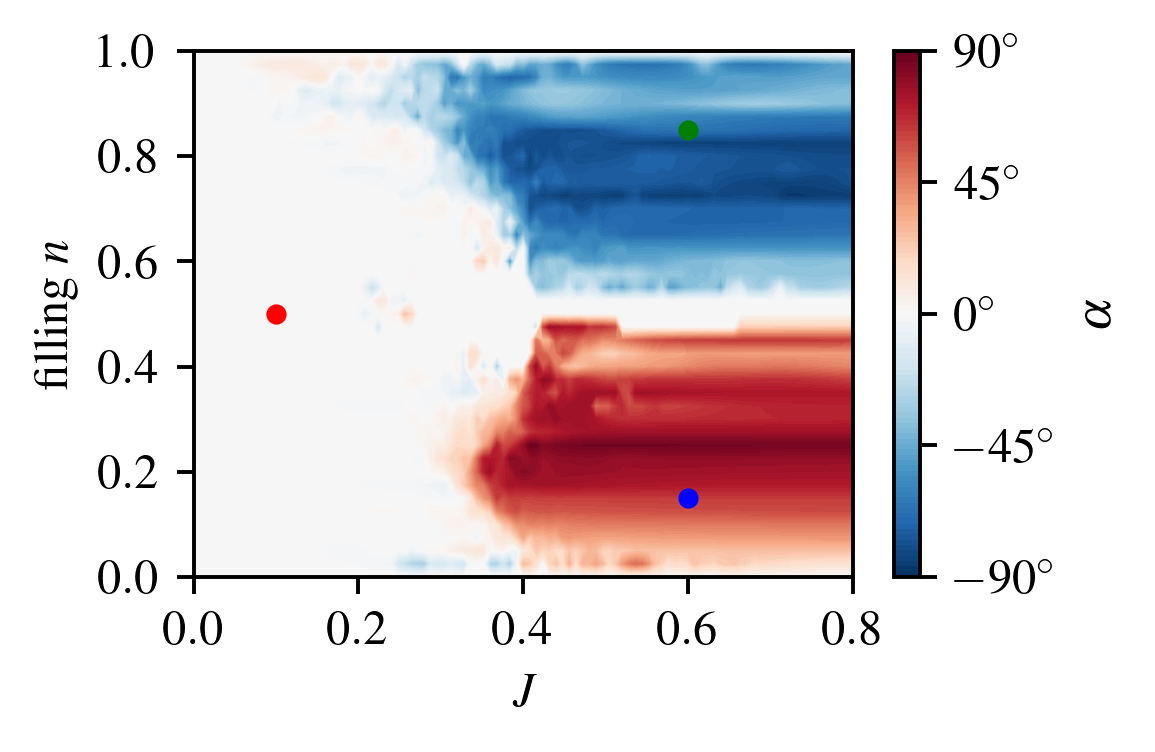

In [19]:
fig, ax = plt.subplots(1, 1, figsize=(aps_halfwidth, aps_halfwidth * (2 / 3)), dpi=350)

spin_splitter = (
    2
    * np.arctan((conds[:, :, 1] - conds[:, :, 0]) / (conds[:, :, 1] + conds[:, :, 0]))
    * 360
    / (2 * np.pi)
)

total_spin = conds[:, :, 1] + conds[:, :, 0]
spin_splitter[np.where(total_spin <= 0.1)] = 0

clims = np.array([-90, 90])
cax = ax.contourf(
    J_vals,
    fillings,
    # -conds[:, :, 0] + conds[:, :, 1],
    spin_splitter,
    levels=np.linspace(-90, 90, 100),
    cmap="RdBu_r",
    vmin=-90,
    vmax=90,
)


cbar = fig.colorbar(cax, ticks=[-90, -45, 0, 45, 90])
cbar.ax.set_yticklabels(
    [r"$-90^\circ$", r"$-45^\circ$", r"$0^\circ$", r"$45^\circ$", r"$90^\circ$"]
)  #

# cbar = fig.colorbar(im, ax=ax)
# cbar.set_ticks(list(np.linspace(clims[0], clims[1], 5).astype("int")))
# cbar.set_ticklabels()

ax.set_xlabel(r"$J$")
ax.set_ylabel(r"filling $n$")
cbar.set_label(r"$\alpha$")
ax.scatter([point_A[0]], [point_A[1]], color="red", s=10)
ax.scatter([point_B[0]], [point_B[1]], color="blue", s=10)
ax.scatter([point_C[0]], [point_C[1]], color="green", s=10)

plt.tight_layout()

plt.savefig("paper_figs/fig_3b.pdf", transparent=True)

plt.show()

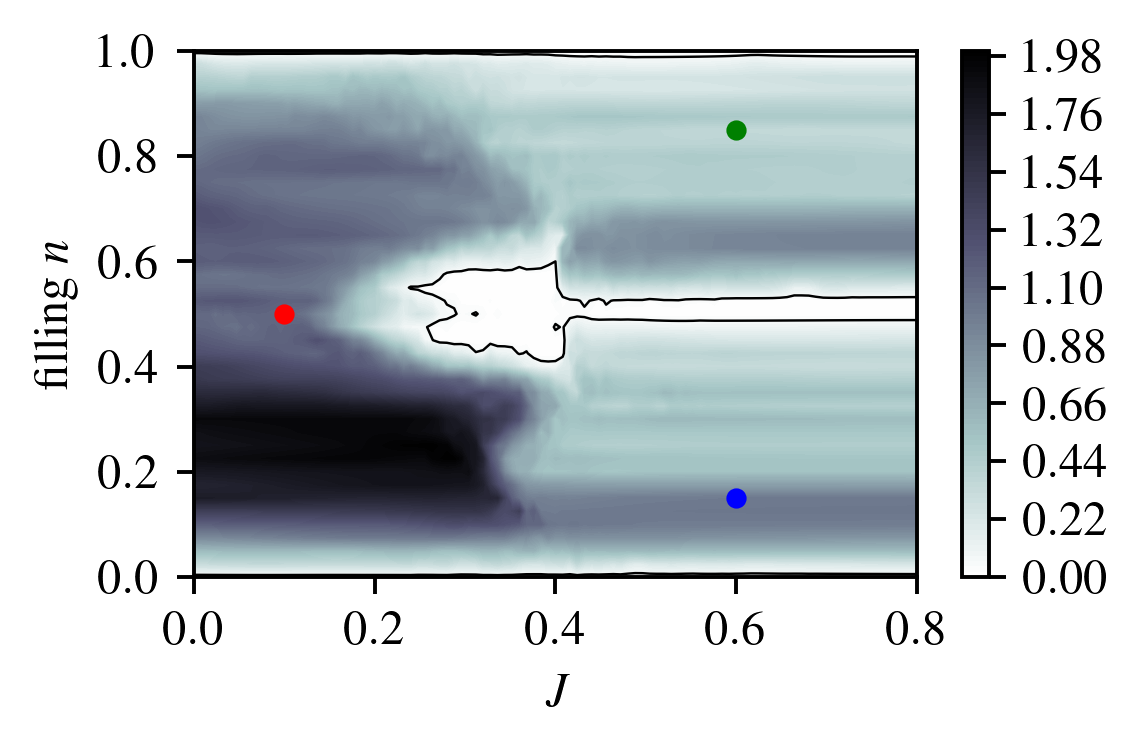

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(aps_halfwidth, aps_halfwidth * (2 / 3)), dpi=350)

spin_splitter = (
    2
    * np.arctan((conds[:, :, 1] - conds[:, :, 0]) / (conds[:, :, 1] + conds[:, :, 0]))
    * 360
    / (2 * np.pi)
)

total_spin = conds[:, :, 1] + conds[:, :, 0]
spin_splitter[np.where(total_spin <= 0.1)] = 0

# clims = np.array([-90, 90])
cax = ax.contourf(
    J_vals,
    fillings,
    conds[:, :, 0] + conds[:, :, 1],
    levels=100,
    cmap="bone_r",
)


# cbar = fig.colorbar(cax, ticks=[-90,-45,  0,45,  90])
# cbar.ax.set_yticklabels(['-90', '-45', '0', '45', '90'])  #

cbar = fig.colorbar(cax, ax=ax)
# cbar.set_ticks(list(np.linspace(clims[0], clims[1], 5).astype("int")))
# cbar.set_ticklabels()

ax.set_xlabel(r"$J$")
ax.set_ylabel(r"filling $n$")
# cbar.set_label(r"$\alpha$")
ax.scatter([point_A[0]], [point_A[1]], color="red", s=10)
ax.scatter([point_B[0]], [point_B[1]], color="blue", s=10)
ax.scatter([point_C[0]], [point_C[1]], color="green", s=10)

plt.tight_layout()
cax = ax.contour(
    J_vals,
    fillings,
    conds[:, :, 0] + conds[:, :, 1],
    levels=[0.05],
    colors="black",
    linewidths=0.5,
)
# plt.savefig("paper_figs/fig_3b.pdf", transparent=True)

plt.show()

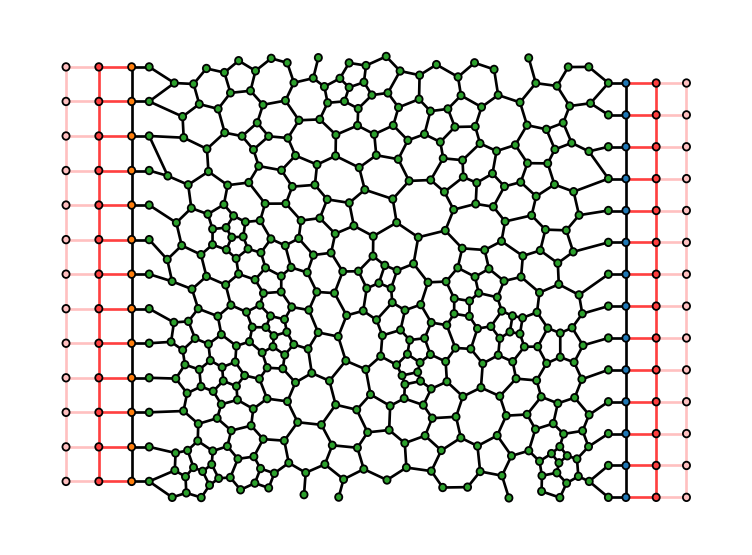

In [16]:
from alter_morph.hamiltonians import alt_hamiltonian

# plot the lattice

hamiltonian = alt_hamiltonian(lattice, 1, 0.5, 0.5, 0.5, m, n)
contact_lattice, k_lattice, k_system, contact_vertices = (
    crack_hamiltonian_for_contacts_kwant(lattice, hamiltonian)
)
kwant_system_with_leads, left_lead, right_lead = attach_leads_to_cracked(
    contact_lattice,
    k_lattice,
    k_system,
    contact_vertices,
    np.diag([-1, -1, 1, 1]),
    np.diag([-1, -1, 1, 1]),
    np.diag([-1, -1, 1, 1]),
)


fig, ax = plt.subplots(
    1, 1, figsize=(aps_halfwidth * (1 / 1.5), aps_halfwidth * (1 / 2)), dpi=350
)
kwant.plot(
    kwant_system_with_leads,
    site_lw=0.2,
    colorbar=False,
    show=False,
    ax=ax,
    lead_hop_lw=0.3,
    hop_lw=0.3,
    site_size=0.4,
)
ax.axis("off")

plt.tight_layout()
# plt.savefig("paper_figs/fig_3c.pdf", transparent=True)